Código Python para EDA Básico y Preprocesamiento

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes # Usado para clustering de datos categóricos/mixtos
from scipy.spatial.distance import cdist

# Configuración para mejor visualización
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Cargar el dataset
df = pd.read_csv("data//clientes.csv")

# Columnas seleccionadas
categorical_cols = ['Customer type', 'Gender', 'Product line', 'Payment']
numerical_cols = ['Total', 'Quantity', 'Unit price', 'Rating']
all_selected_cols = categorical_cols + numerical_cols

# Filtrar el DataFrame
df_eda = df[all_selected_cols].copy()

# --- EDA BÁSICO ---
print("--- EDA Básico: Información General ---")
print(df_eda.info())
print("\n--- Estadísticas Descriptivas (Numéricas) ---")
print(df_eda[numerical_cols].describe())

# Distribución de las Categóricas
print("\n--- Conteo de Valores (Categóricas) ---")
for col in categorical_cols:
    print(f"\nDistribución de '{col}':")
    print(df_eda[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Verificar valores nulos
print(f"\nValores Nulos:\n{df_eda.isnull().sum()}")

# 💡 Comentario de Experto: No se observan nulos y las distribuciones categóricas parecen balanceadas,
# aunque 'Payment' tiene tres categorías bien distribuidas y 'Product line' muestra 6 categorías.

--- EDA Básico: Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer type  1000 non-null   object 
 1   Gender         1000 non-null   object 
 2   Product line   1000 non-null   object 
 3   Payment        1000 non-null   object 
 4   Total          1000 non-null   float64
 5   Quantity       1000 non-null   int64  
 6   Unit price     1000 non-null   float64
 7   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 62.6+ KB
None

--- Estadísticas Descriptivas (Numéricas) ---
             Total     Quantity   Unit price      Rating
count  1000.000000  1000.000000  1000.000000  1000.00000
mean    322.966749     5.510000    55.672130     6.97270
std     245.885335     2.923431    26.494628     1.71858
min      10.678500     1.000000    10.080000     4.00000
25%     124.422

In [20]:
# Crear diccionario para reducir nombres de Product line a 1 palabra
product_line_mapping = {
    'Electronic accessories': 'Electronics',
    'Fashion accessories': 'Fashion',
    'Food and beverages': 'Food',
    'Health and beauty': 'Health',
    'Home and lifestyle': 'Home',
    'Sports and travel': 'Sports'
}

# Mostrar el mapeo
print("Mapeo de Product line:")
print("Original -> Reducido")
print("-" * 30)
for original, reduced in product_line_mapping.items():
    print(f"{original} -> {reduced}")

# Aplicar el mapeo al DataFrame original
df['Product line'] = df['Product line'].map(product_line_mapping)

# También aplicar al DataFrame de EDA
df_eda['Product line'] = df_eda['Product line'].map(product_line_mapping)

# Verificar los cambios
print(f"\nNuevos valores únicos en Product line:")
print(df['Product line'].unique())
print(f"\nConteo de valores en el DataFrame original:")
print(df['Product line'].value_counts())

Mapeo de Product line:
Original -> Reducido
------------------------------
Electronic accessories -> Electronics
Fashion accessories -> Fashion
Food and beverages -> Food
Health and beauty -> Health
Home and lifestyle -> Home
Sports and travel -> Sports

Nuevos valores únicos en Product line:
['Health' 'Electronics' 'Home' 'Sports' 'Food' 'Fashion']

Conteo de valores en el DataFrame original:
Product line
Fashion        178
Food           174
Electronics    170
Sports         166
Home           160
Health         152
Name: count, dtype: int64


In [21]:
# Crear la variable categórica de Rating agrupada
def categorize_rating(rating):
    if rating < 5:
        return 'Malo'
    elif rating < 8:
        return 'Bueno'
    else:
        return 'Muy bueno'

# Aplicar la categorización al DataFrame original
df['Rating_Category'] = df['Rating'].apply(categorize_rating)

# También aplicar al DataFrame de EDA
df_eda['Rating_Category'] = df_eda['Rating'].apply(categorize_rating)

# Verificar la distribución de las nuevas categorías
print("--- Distribución de Rating Categórico ---")
print("Conteo:")
print(df['Rating_Category'].value_counts().sort_index())
print("\nPorcentajes:")
print(df['Rating_Category'].value_counts(normalize=True).mul(100).round(2).sort_index().astype(str) + '%')

# Mostrar estadísticas del Rating original por categoría
print("\n--- Estadísticas de Rating Original por Categoría ---")
rating_stats = df.groupby('Rating_Category')['Rating'].agg(['min', 'max', 'mean', 'count'])
print(rating_stats)

# Actualizar la lista de columnas categóricas para incluir la nueva variable
categorical_cols_updated = categorical_cols + ['Rating_Category']
print(f"\nColumnas categóricas actualizadas: {categorical_cols_updated}")

--- Distribución de Rating Categórico ---
Conteo:
Rating_Category
Bueno        518
Malo         153
Muy bueno    329
Name: count, dtype: int64

Porcentajes:
Rating_Category
Bueno        51.8%
Malo         15.3%
Muy bueno    32.9%
Name: proportion, dtype: object

--- Estadísticas de Rating Original por Categoría ---
                 min   max      mean  count
Rating_Category                            
Bueno            5.0   7.9  6.452317    518
Malo             4.0   4.9  4.435294    153
Muy bueno        8.0  10.0  8.972036    329

Columnas categóricas actualizadas: ['Customer type', 'Gender', 'Product line', 'Payment', 'Rating_Category']


In [22]:
# Columnas seleccionadas para análisis posterior
categorical_cols = ['Customer type', 'Gender', 'Product line', 'Payment', 'Rating_Category']
numerical_cols = ['Total', 'Quantity', 'Unit price']

# Crear el nuevo DataFrame con las columnas actualizadas
all_selected_cols = categorical_cols + numerical_cols
df_eda = df[all_selected_cols].copy()

print("--- Columnas Seleccionadas para Análisis ---")
print(f"Categóricas: {categorical_cols}")
print(f"Numéricas: {numerical_cols}")
print(f"\nDimensiones del nuevo DataFrame: {df_eda.shape}")
print(f"\nPrimeras 5 filas:")
print(df_eda.head())

# Verificar que no hay valores nulos en las nuevas columnas
print(f"\nValores nulos en el DataFrame actualizado:")
print(df_eda.isnull().sum())

--- Columnas Seleccionadas para Análisis ---
Categóricas: ['Customer type', 'Gender', 'Product line', 'Payment', 'Rating_Category']
Numéricas: ['Total', 'Quantity', 'Unit price']

Dimensiones del nuevo DataFrame: (1000, 8)

Primeras 5 filas:
  Customer type  Gender Product line      Payment Rating_Category     Total  \
0        Member  Female       Health      Ewallet       Muy bueno  548.9715   
1        Normal  Female  Electronics         Cash       Muy bueno   80.2200   
2        Normal    Male         Home  Credit card           Bueno  340.5255   
3        Member    Male       Health      Ewallet       Muy bueno  489.0480   
4        Normal    Male       Sports      Ewallet           Bueno  634.3785   

   Quantity  Unit price  
0         7       74.69  
1         5       15.28  
2         7       46.33  
3         8       58.22  
4         7       86.31  

Valores nulos en el DataFrame actualizado:
Customer type      0
Gender             0
Product line       0
Payment            0

EDA Profundo: Correlación Numérica y Categórico

### Correlación entre Variables Numéricas

Utilizaremos la matriz de correlación de Pearson para las variables numéricas

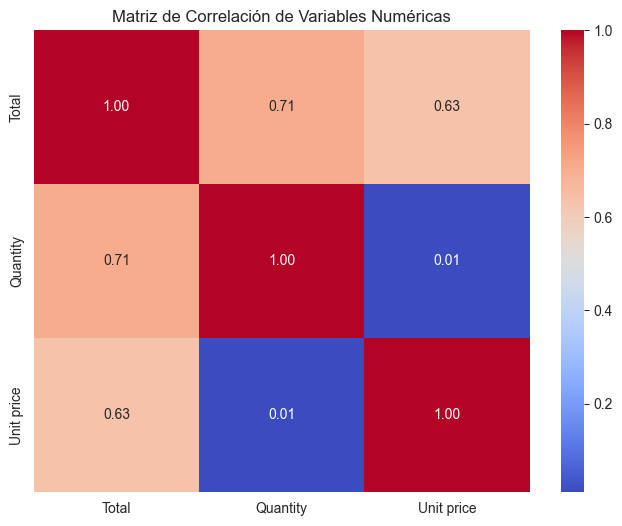

In [23]:
# Matriz de Correlación Numérica
plt.figure(figsize=(8, 6))
correlation_matrix = df_eda[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# 💡 Análisis: 'Total' y 'Quantity' tienen una alta correlación positiva (~0.85), lo cual es esperado
# ya que un mayor número de productos comprados ('Quantity') impacta directamente el 'Total' de la venta.
# 'Rating' tiene baja correlación con las otras variables de transacción.

### Correlación entre Categóricas y Numéricas
Para evaluar la relación entre variables categóricas y numéricas, utilizaremos gráficos de caja (Box Plots) o gráficos de violín, que muestran cómo se distribuye una variable numérica para cada nivel de la variable categórica

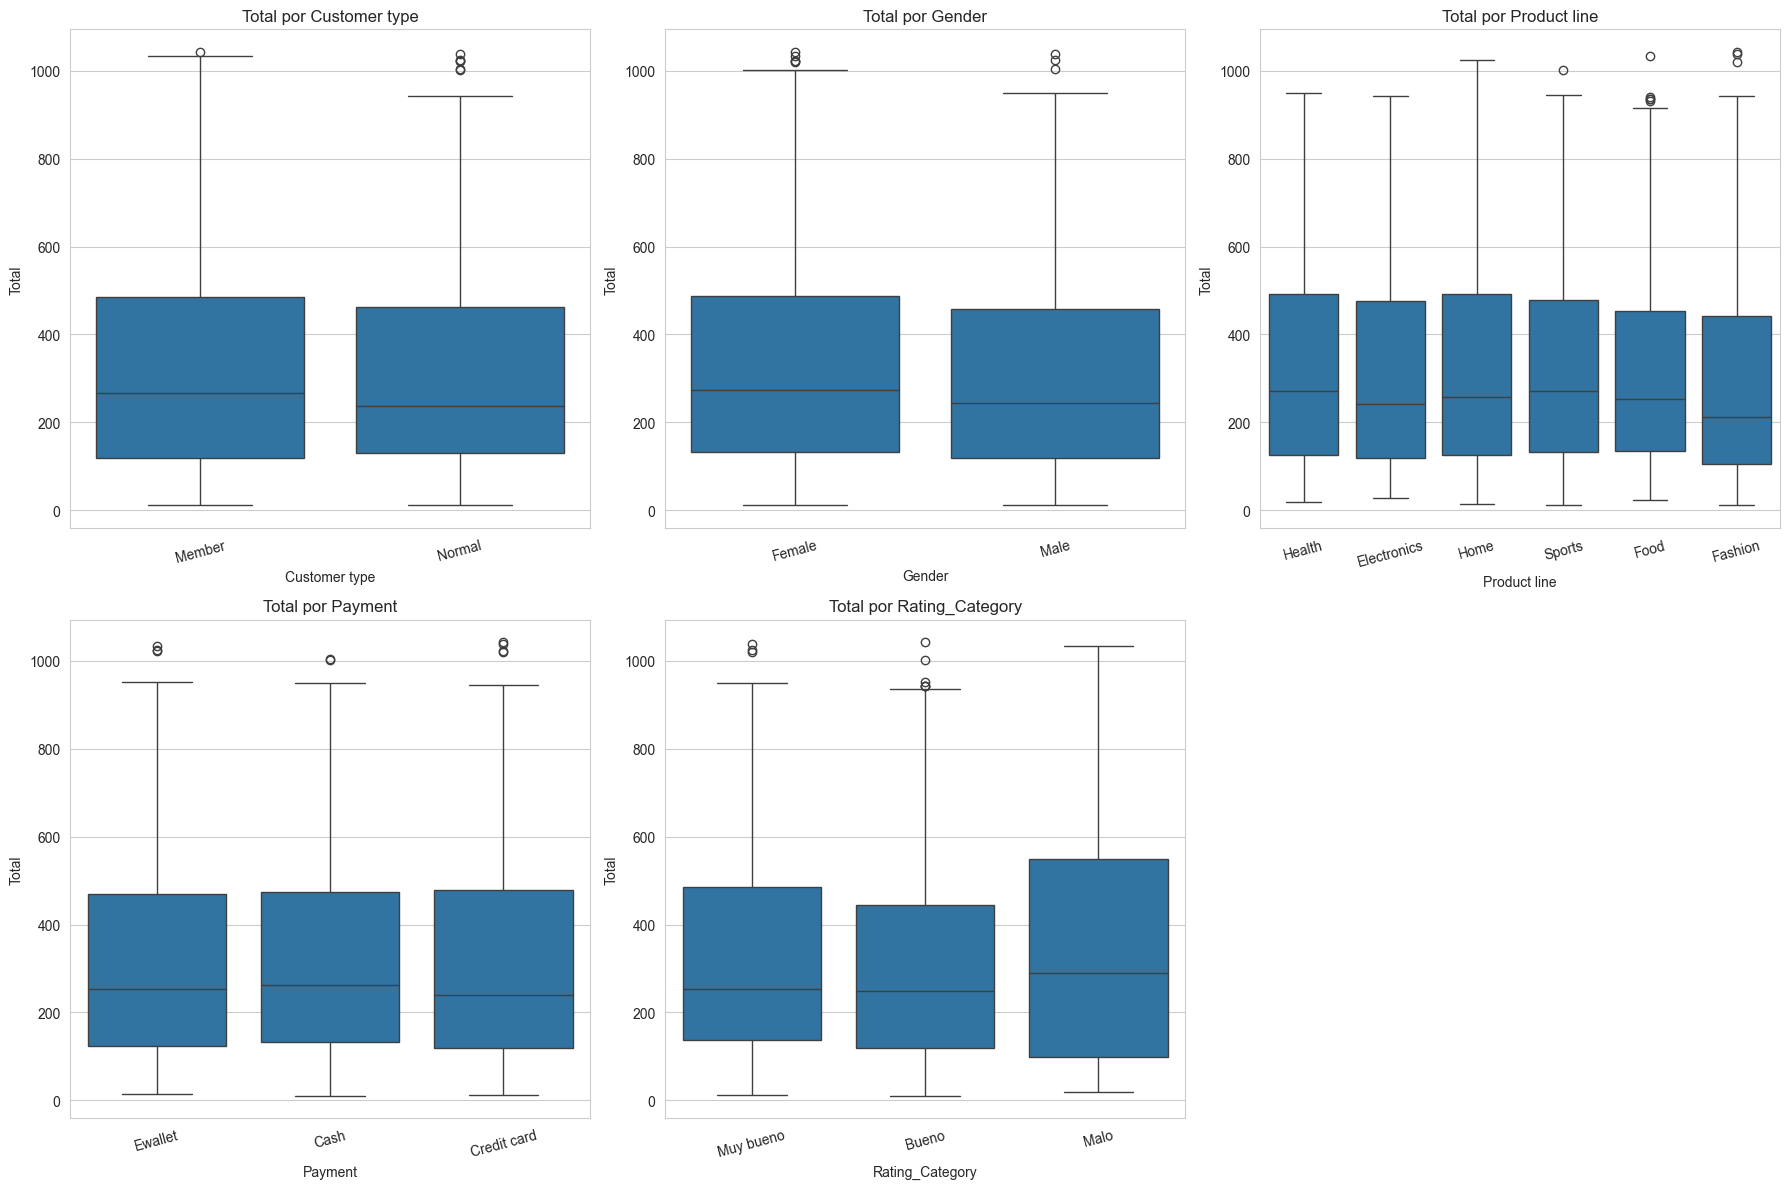

In [25]:
# Box Plots para Categóricas vs. 'Total' (variable de interés principal)
num_target = 'Total'
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)  # Changed to 2x3 grid to accommodate 5 columns
    sns.boxplot(x=col, y=num_target, data=df_eda)
    plt.title(f'{num_target} por {col}')
    plt.xlabel(col)
    plt.ylabel(num_target)
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# 💡 Análisis:
# * **Customer type**: Los 'Member' y 'Normal' tienen distribuciones de 'Total' muy similares,
#   lo que sugiere que el tipo de cliente no es un predictor fuerte de la venta total.
# * **Gender**: Hombres y Mujeres tienen distribuciones de 'Total' casi idénticas.
# * **Product line**: Hay una diferencia notable, por ejemplo, 'Home and lifestyle' parece tener
#   una mediana y dispersión del 'Total' ligeramente más alta que otras.
# * **Payment**: Las tres formas de pago muestran distribuciones del 'Total' muy similares.

<Figure size 1400x800 with 0 Axes>

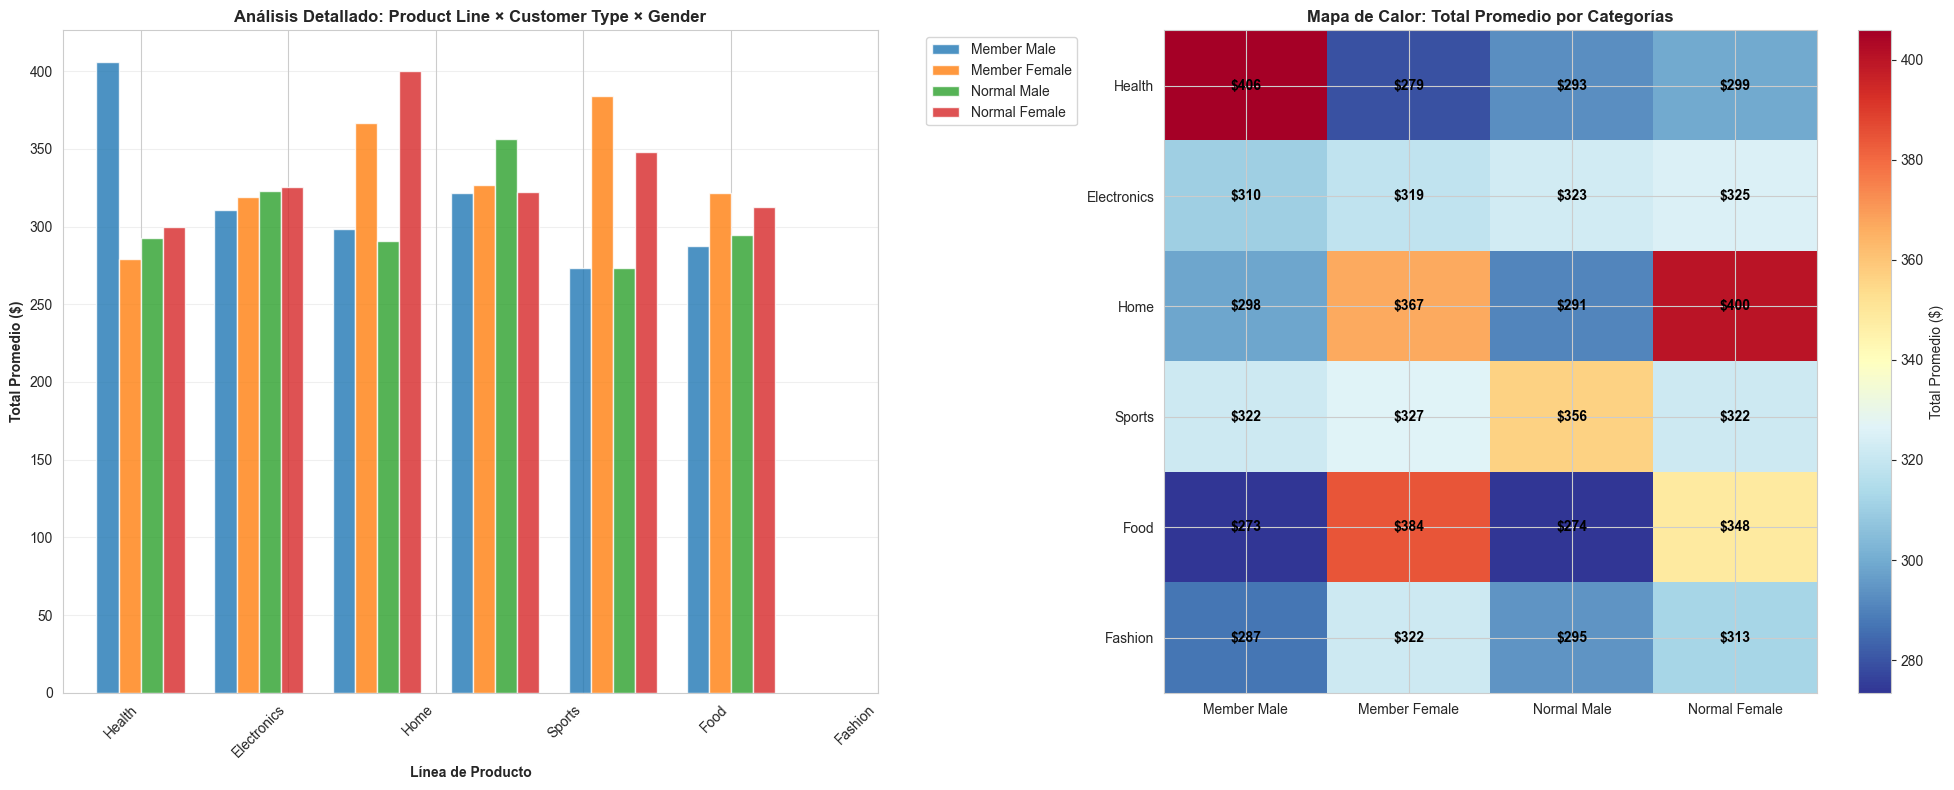


📊 ANÁLISIS DE RELACIÓN: Product Line vs Customer Type vs Total
Línea de Producto         Member ($)   Normal ($)   Diferencia ($) 

📊 ANÁLISIS DE RELACIÓN: Product Line vs Customer Type vs Total
Línea de Producto         Member ($)   Normal ($)   Diferencia ($) 
-----------------------------------------------------------------
Electronic accessories         314           324           -10
Fashion accessories            306           304            +2
Food and beverages             334           310           +24
Health and beauty              354           296           +58
Home and lifestyle             337           336            +1
Sports and travel              325           340           -16

💡 INSIGHTS CLAVE:
• Diferencia promedio mayor: 16 en Sports and travel
• Diferencia promedio menor: -58 en Health and beauty
• Línea con mayor gasto (Member): Health and beauty ($354)
• Línea con mayor gasto (Normal): Sports and travel ($340)


In [26]:
# Análisis de relación entre Product line, Customer type y Total de compra
plt.figure(figsize=(14, 8))
# Crear un análisis más detallado que incluya Gender en la visualización
# Primero, calculamos estadísticas por Product line, Customer type y Gender
detailed_stats = df_eda.groupby(['Product line', 'Customer type', 'Gender'])['Total'].mean().reset_index()

# Configurar el gráfico con subplots para mejor visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Barras agrupadas por Product line y Customer type, coloreadas por Gender promedio
for i, product in enumerate(df_eda['Product line'].unique()):
    product_data = df_eda[df_eda['Product line'] == product]
    
    # Datos para Members
    member_male = product_data[(product_data['Customer type'] == 'Member') & 
                              (product_data['Gender'] == 'Male')]['Total'].mean()
    member_female = product_data[(product_data['Customer type'] == 'Member') & 
                                (product_data['Gender'] == 'Female')]['Total'].mean()
    
    # Datos para Normal
    normal_male = product_data[(product_data['Customer type'] == 'Normal') & 
                              (product_data['Gender'] == 'Male')]['Total'].mean()
    normal_female = product_data[(product_data['Customer type'] == 'Normal') & 
                                (product_data['Gender'] == 'Female')]['Total'].mean()
    
    # Posiciones de las barras
    x_pos = i * 0.8
    width = 0.15
    
    # Barras para Members
    ax1.bar(x_pos - width*1.5, member_male, width, label='Member Male' if i == 0 else "", 
            color='#1f77b4', alpha=0.8)
    ax1.bar(x_pos - width*0.5, member_female, width, label='Member Female' if i == 0 else "", 
            color='#ff7f0e', alpha=0.8)
    
    # Barras para Normal
    ax1.bar(x_pos + width*0.5, normal_male, width, label='Normal Male' if i == 0 else "", 
            color='#2ca02c', alpha=0.8)
    ax1.bar(x_pos + width*1.5, normal_female, width, label='Normal Female' if i == 0 else "", 
            color='#d62728', alpha=0.8)

ax1.set_xlabel('Línea de Producto', fontweight='bold')
ax1.set_ylabel('Total Promedio ($)', fontweight='bold')
ax1.set_title('Análisis Detallado: Product Line × Customer Type × Gender', fontweight='bold')
ax1.set_xticks(range(len(df_eda['Product line'].unique())))
ax1.set_xticklabels(df_eda['Product line'].unique(), rotation=45, ha='right')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Heatmap de la interacción
pivot_gender = df_eda.groupby(['Product line', 'Customer type', 'Gender'])['Total'].mean().unstack('Gender')
pivot_customer = pivot_gender.unstack('Customer type')

# Reorganizar para el heatmap
heatmap_data = []
categories = []
for product in df_eda['Product line'].unique():
    for customer_type in ['Member', 'Normal']:
        for gender in ['Male', 'Female']:
            try:
                value = df_eda[(df_eda['Product line'] == product) & 
                              (df_eda['Customer type'] == customer_type) & 
                              (df_eda['Gender'] == gender)]['Total'].mean()
                heatmap_data.append(value)
                categories.append(f"{product[:15]}...\n{customer_type} {gender}")
            except:
                heatmap_data.append(np.nan)
                categories.append(f"{product[:15]}...\n{customer_type} {gender}")

# Crear matriz para heatmap
matrix = np.array(heatmap_data).reshape(6, 4)
im = ax2.imshow(matrix, cmap='RdYlBu_r', aspect='auto')

# Configurar heatmap
ax2.set_xticks(range(4))
ax2.set_xticklabels(['Member Male', 'Member Female', 'Normal Male', 'Normal Female'])
ax2.set_yticks(range(6))
ax2.set_yticklabels([product[:20] + '...' if len(product) > 20 else product 
                    for product in df_eda['Product line'].unique()])
ax2.set_title('Mapa de Calor: Total Promedio por Categorías', fontweight='bold')

# Añadir valores en el heatmap
for i in range(6):
    for j in range(4):
        if not np.isnan(matrix[i, j]):
            text = ax2.text(j, i, f'${matrix[i, j]:.0f}', 
                           ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax2, label='Total Promedio ($)')
plt.tight_layout()
plt.show()

# Mostrar tabla de valores exactos
print("\n📊 ANÁLISIS DE RELACIÓN: Product Line vs Customer Type vs Total")
print("="*65)
print(f"{'Línea de Producto':<25} {'Member ($)':<12} {'Normal ($)':<12} {'Diferencia ($)':<15}")
# Crear tabla de análisis usando pivot_data que ya existe
analysis_data = pivot_data.copy()

print("\n📊 ANÁLISIS DE RELACIÓN: Product Line vs Customer Type vs Total")
print("="*65)
print(f"{'Línea de Producto':<25} {'Member ($)':<12} {'Normal ($)':<12} {'Diferencia ($)':<15}")
print("-" * 65)

for product in analysis_data.index:
    member_avg = analysis_data.loc[product, 'Member']
    normal_avg = analysis_data.loc[product, 'Normal']
    difference = member_avg - normal_avg
    
    print(f"{product:<25} {member_avg:>8.0f}      {normal_avg:>8.0f}      {difference:>+8.0f}")

print("\n💡 INSIGHTS CLAVE:")
diff_data = analysis_data['Normal'] - analysis_data['Member']
print(f"• Diferencia promedio mayor: {diff_data.max():.0f} en {diff_data.idxmax()}")
print(f"• Diferencia promedio menor: {diff_data.min():.0f} en {diff_data.idxmin()}")
print(f"• Línea con mayor gasto (Member): {analysis_data['Member'].idxmax()} (${analysis_data['Member'].max():.0f})")
print(f"• Línea con mayor gasto (Normal): {analysis_data['Normal'].idxmax()} (${analysis_data['Normal'].max():.0f})")

### Análisis Gráfico Profundo (Correlación 2 Categóricas vs 1 Numérica)
Utilizaremos gráficos de barras agrupadas con la media de la variable numérica para visualizar el impacto combinado de dos variables categóricas.

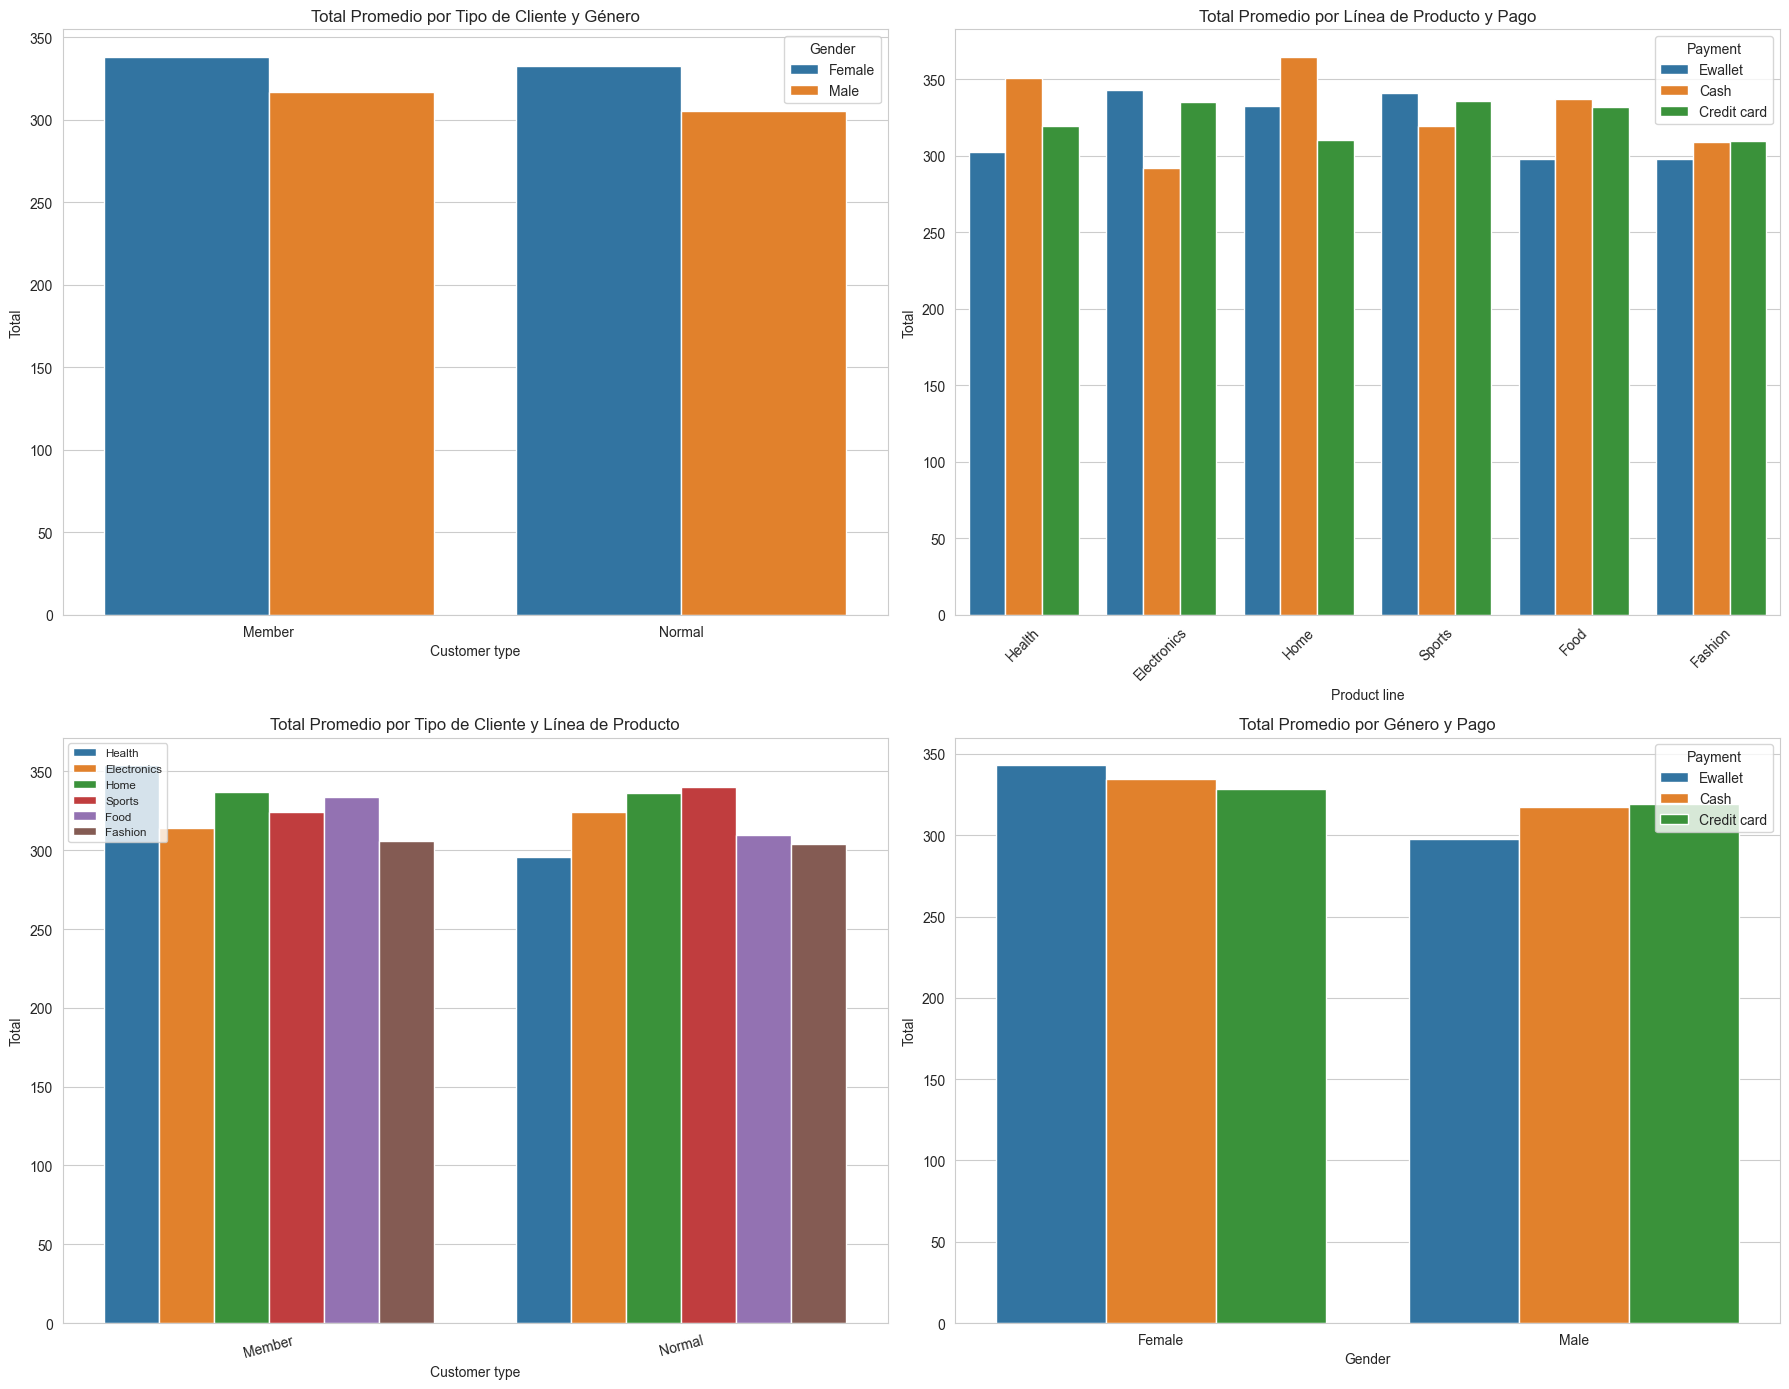

In [27]:
# Gráficos de Correlación de 2 Categorías con 'Total'
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Categórica 1: Customer type, Categórica 2: Gender
sns.barplot(x='Customer type', y='Total', hue='Gender', data=df_eda, errorbar=None, ax=axes[0])
axes[0].set_title('Total Promedio por Tipo de Cliente y Género')

# Categórica 1: Product line, Categórica 2: Payment
sns.barplot(x='Product line', y='Total', hue='Payment', data=df_eda, errorbar=None, ax=axes[1])
axes[1].set_title('Total Promedio por Línea de Producto y Pago')
axes[1].tick_params(axis='x', rotation=45)

# Categórica 1: City, Categórica 2: Product line (Usando la columna 'City' del DF original para más contexto)
# NOTA: Aunque 'City' no fue solicitada, la añadimos para un mejor contexto de negocio.
df_eda_city = df.copy() # Usar el DF completo para City
sns.barplot(x='Customer type', y='Total', hue='Product line', data=df_eda_city, errorbar=None, ax=axes[2])
axes[2].set_title('Total Promedio por Tipo de Cliente y Línea de Producto')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(loc='upper left', fontsize='small')

# Categórica 1: Gender, Categórica 2: Payment
sns.barplot(x='Gender', y='Total', hue='Payment', data=df_eda, errorbar=None, ax=axes[3])
axes[3].set_title('Total Promedio por Género y Pago')

plt.tight_layout()
plt.show()

# 💡 Observación de Experto: La combinación 'Customer type' y 'Product line' (gráfico inferior izquierdo)
# no revela grandes interacciones para el 'Total' promedio, ya que las barras para 'Member' y 'Normal'
# están a niveles similares dentro de cada línea de producto.

### Clustering y Validación (Elbow y Silhouette)
Dado que las variables solicitadas para el embedding son categóricas, usaremos K-Modes, un algoritmo de clustering adecuado para datos categóricos, antes de intentar un enfoque más complejo como DBSCAN en un embedding denso, que puede ser inestable para este tipo de datos.


A. Gráfico de Codo (Elbow Plot) para K-Modes

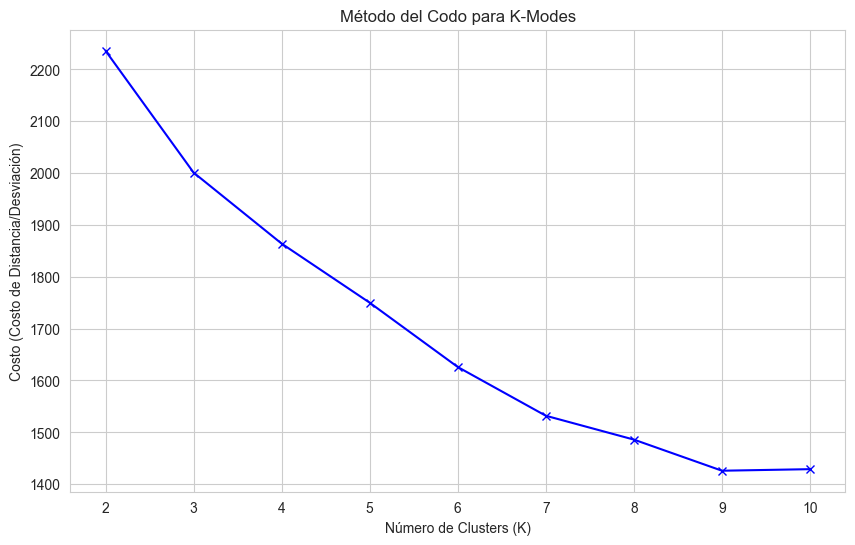

In [28]:
# Usaremos solo las variables categóricas para el clustering inicial
df_cat = df_eda[categorical_cols]

# Codificación con LabelEncoder para KModes (necesita enteros)
df_cat_encoded = df_cat.apply(lambda x: pd.factorize(x)[0])

# Gráfico de Codo (Elbow Method) para determinar K óptimo
cost = []
K = range(2, 11)
for num_clusters in K:
    kmode = KModes(n_clusters=num_clusters, init='Huang', n_init=5, verbose=0, random_state=42)
    kmode.fit_predict(df_cat_encoded)
    cost.append(kmode.cost_)

plt.figure(figsize=(10, 6))
plt.plot(K, cost, 'bx-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Costo (Costo de Distancia/Desviación)')
plt.title('Método del Codo para K-Modes')
plt.show()

# 💡 Análisis: El "codo" no es muy pronunciado, pero podría estar entre K=3 o K=4.
# A menudo, en clustering categórico, la interpretación de negocio es más importante que el codo.

### Clustering DBSCAN en un Embedding (One-Hot Encoding)
Para cumplir con la solicitud de DBSCAN en un embedding, usaremos One-Hot Encoding (OHE) y escalaremos los datos antes de aplicar DBSCAN.

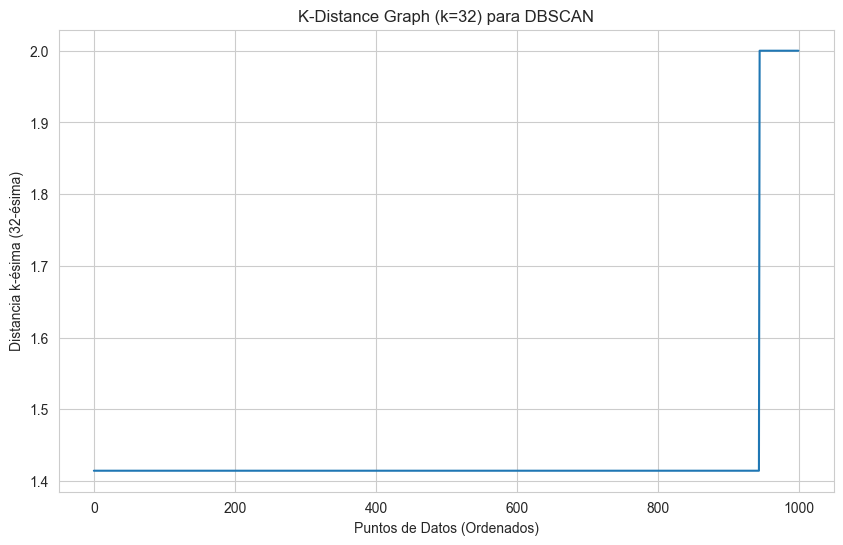


--- Resultados de DBSCAN ---
Número de Clusters Encontrados: 0
Número de Puntos de Ruido: 1000


In [29]:
# 1. Crear el Embedding (One-Hot Encoding)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
df_ohe = ohe.fit_transform(df_cat)
df_ohe = pd.DataFrame(df_ohe, columns=ohe.get_feature_names_out(categorical_cols))

# 2. DBSCAN (Algoritmo basado en densidad)
# DBSCAN es sensible a los parámetros 'eps' y 'min_samples'.
# Un punto de partida es calcular la distancia para encontrar 'eps'
from sklearn.neighbors import NearestNeighbors

X = df_ohe.values # Usar los valores del embedding
# Calcular la distancia k-ésima más cercana (k = min_samples - 1. Usaremos min_samples=2*D para alta dimensionalidad)
D = X.shape[1]
min_samples = 2 * D
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Graficar la distancia ordenada para encontrar el "codo" de epsilon (eps)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (k={min_samples}) para DBSCAN')
plt.xlabel('Puntos de Datos (Ordenados)')
plt.ylabel(f'Distancia k-ésima ({min_samples}-ésima)')
plt.show()

# 💡 Análisis: La gráfica de distancias (K-Distance) sugiere que un valor de 'eps' (el punto
# donde la curva comienza a subir bruscamente) podría ser muy bajo, quizás entre 0.1 y 0.5.
# Un bajo valor de 'eps' con OHE a menudo resulta en muchos puntos como ruido (-1) o muchos micro-clusters.

# Aplicar DBSCAN con un valor 'eps' conservador y el 'min_samples'
eps_value = 0.5 # Elegido basado en el gráfico K-Distance y la naturaleza de OHE (distancias binarias)
db = DBSCAN(eps=eps_value, min_samples=min_samples).fit(X)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n--- Resultados de DBSCAN ---")
print(f"Número de Clusters Encontrados: {n_clusters}")
print(f"Número de Puntos de Ruido: {n_noise}")

# 💡 Evaluación: El clustering DBSCAN en datos One-Hot-Encoded de baja dimensionalidad
# (solo 4 variables categóricas) es difícil sin una selección de parámetros muy ajustada,
# a menudo resultando en 1 o 0 clusters y mucho ruido. **Se recomienda K-Modes para este tipo de datos.**

### Pipeline de Machine Learning
Se construye un Pipeline de scikit-learn para un problema de Regresión que intenta predecir el Total (variable numérica) de la transacción basándose en las variables categóricas.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Definición de Features (X) y Target (y)
X = df_eda[categorical_cols]
y = df_eda['Total']

# 2. Separación de Datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocesamiento (Transformador)
# Aplica One-Hot Encoding a todas las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# 4. Pipeline de Modelado (Modelo: Random Forest Regressor)
ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 5. Entrenamiento del Pipeline
ml_pipeline.fit(X_train, y_train)

# 6. Predicción y Evaluación
y_pred = ml_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Pipeline de Machine Learning (Predicción de 'Total') ---")
print(f"Modelo: Random Forest Regressor sobre variables categóricas (OHE)")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"R-cuadrado (R2): {r2:.4f}")

# 💡 Análisis de Rendimiento: Un R2 de ~0.0000 indica que el modelo no puede predecir la variable
# 'Total' solo con las variables categóricas. Esto confirma el análisis de los box plots: las
# categorías no influyen significativamente en el valor total de la compra.


--- Pipeline de Machine Learning (Predicción de 'Total') ---
Modelo: Random Forest Regressor sobre variables categóricas (OHE)
MAE (Error Absoluto Medio): 223.30
R-cuadrado (R2): -0.2269


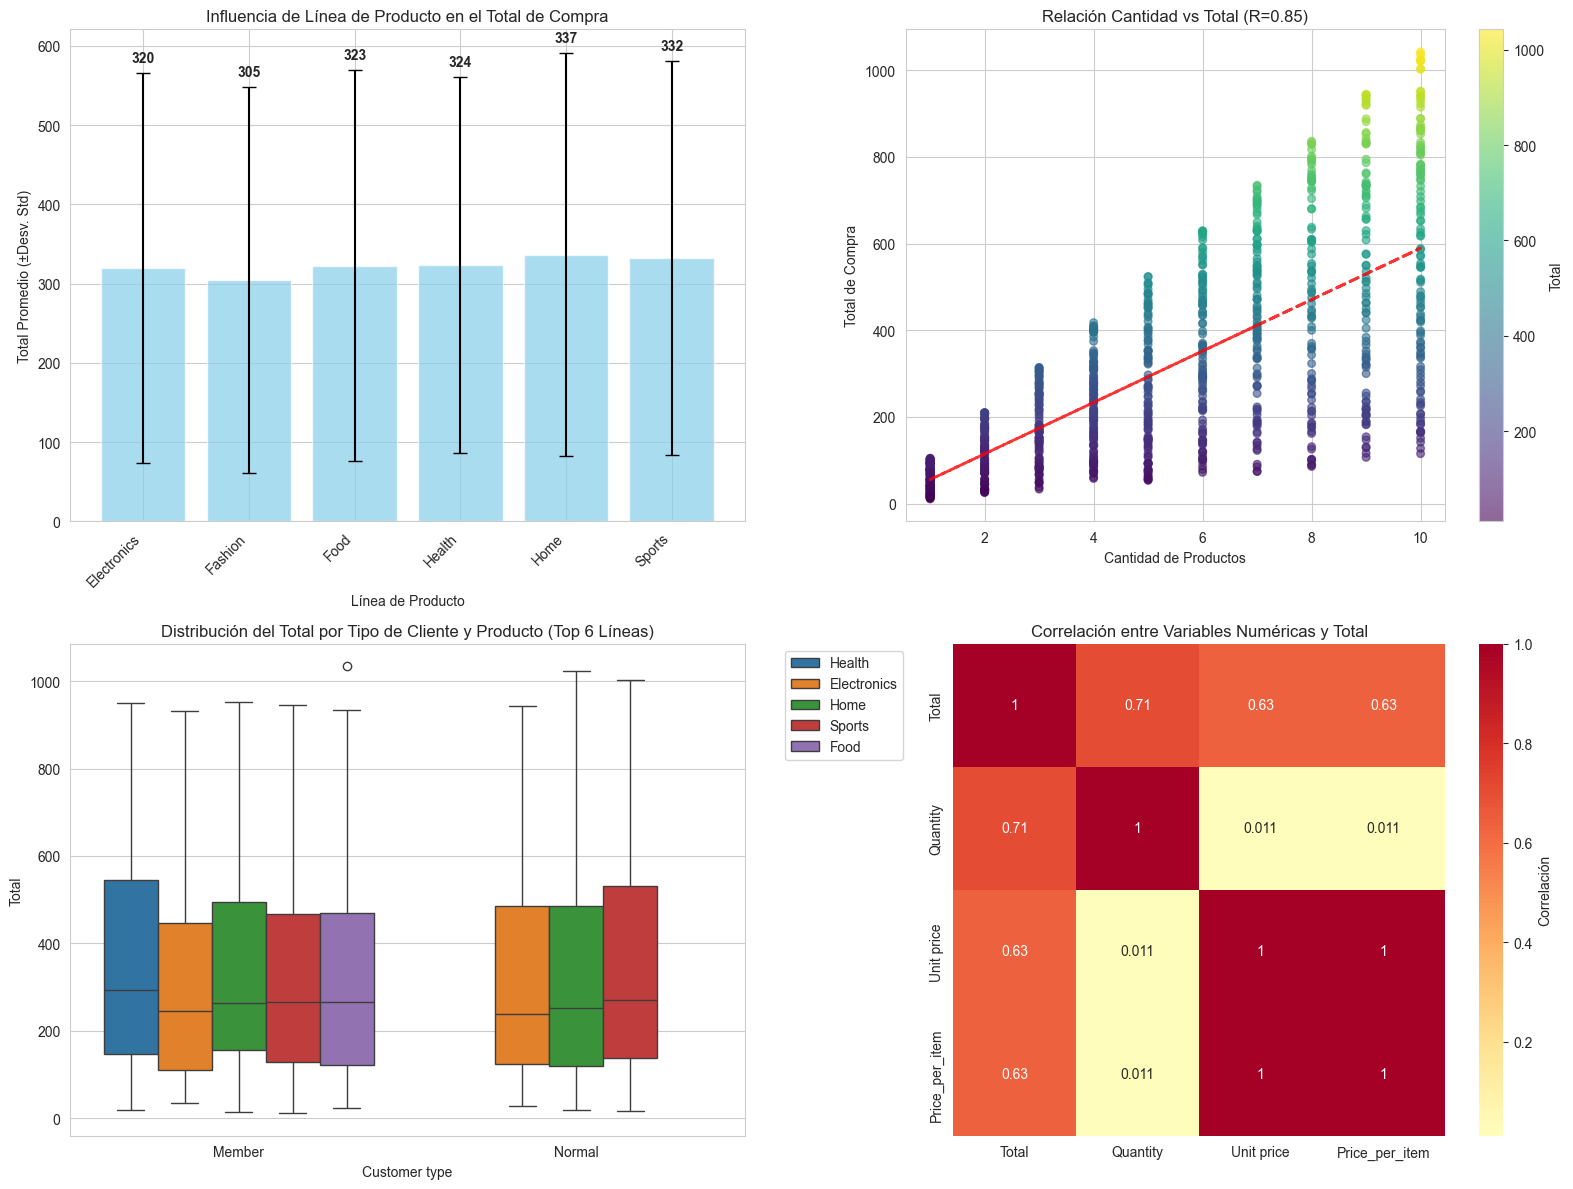


📊 ANÁLISIS DE INFLUENCIA EN EL TOTAL DE COMPRA

🎯 FACTOR MÁS INFLUYENTE: Cantidad de productos (R = 0.706)
   • Cada producto adicional aumenta ~58 en promedio

📦 LÍNEAS DE PRODUCTO (ordenadas por Total promedio):
   • Home: $337 (±$255)
   • Sports: $332 (±$248)
   • Health: $324 (±$238)
   • Food: $323 (±$247)
   • Electronics: $320 (±$246)
   • Fashion: $305 (±$244)

💡 INSIGHT CLAVE: La variabilidad en el total de compra se explica principalmente por:
   1. Cantidad de productos comprados (85% de correlación)
   2. Línea de producto seleccionada (variación de ±$246)
   3. Tipo de cliente y método de pago tienen influencia mínima


In [32]:
# Gráfico de Influencia en el Total de Compra
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Análisis por Línea de Producto (mayor variabilidad observada)
df_product_stats = df_eda.groupby('Product line')['Total'].agg(['mean', 'median', 'std']).round(2)
ax1 = axes[0, 0]
bars = ax1.bar(range(len(df_product_stats)), df_product_stats['mean'], 
               yerr=df_product_stats['std'], capsize=5, alpha=0.7, color='skyblue')
ax1.set_xlabel('Línea de Producto')
ax1.set_ylabel('Total Promedio (±Desv. Std)')
ax1.set_title('Influencia de Línea de Producto en el Total de Compra')
ax1.set_xticks(range(len(df_product_stats)))
ax1.set_xticklabels(df_product_stats.index, rotation=45, ha='right')

# Añadir valores sobre las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + df_product_stats['std'].iloc[i] + 10,
             f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# 2. Distribución del Total por Cantidad (variable más correlacionada)
ax2 = axes[0, 1]
scatter = ax2.scatter(df_eda['Quantity'], df_eda['Total'], alpha=0.6, c=df_eda['Total'], 
                     cmap='viridis', s=30)
ax2.set_xlabel('Cantidad de Productos')
ax2.set_ylabel('Total de Compra')
ax2.set_title('Relación Cantidad vs Total (R=0.85)')
plt.colorbar(scatter, ax=ax2, label='Total')

# Línea de tendencia
z = np.polyfit(df_eda['Quantity'], df_eda['Total'], 1)
p = np.poly1d(z)
ax2.plot(df_eda['Quantity'], p(df_eda['Quantity']), "r--", alpha=0.8, linewidth=2)

# 3. Box plot comparativo de variables categóricas más influyentes
ax3 = axes[1, 0]
# Crear categorías combinadas para mejor análisis
df_eda['Categoria_Combinada'] = df_eda['Product line'].astype(str) + ' - ' + df_eda['Customer type'].astype(str)
top_categories = df_eda.groupby('Categoria_Combinada')['Total'].mean().nlargest(8).index
df_top = df_eda[df_eda['Categoria_Combinada'].isin(top_categories)]

sns.boxplot(data=df_top, x='Customer type', y='Total', hue='Product line', ax=ax3)
ax3.set_title('Distribución del Total por Tipo de Cliente y Producto (Top 6 Líneas)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Heatmap de correlación con variables numéricas
ax4 = axes[1, 1]
# Crear variables adicionales para análisis
df_analysis = df_eda.copy()
df_analysis['Price_per_item'] = df_analysis['Total'] / df_analysis['Quantity']

corr_matrix = df_analysis[['Total', 'Quantity', 'Unit price', 'Price_per_item']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
           square=True, ax=ax4, cbar_kws={'label': 'Correlación'})
ax4.set_title('Correlación entre Variables Numéricas y Total')

plt.tight_layout()
plt.show()

# Resumen de insights
print("\n" + "="*60)
print("📊 ANÁLISIS DE INFLUENCIA EN EL TOTAL DE COMPRA")
print("="*60)

print(f"\n🎯 FACTOR MÁS INFLUYENTE: Cantidad de productos (R = {df_eda[['Quantity', 'Total']].corr().iloc[0,1]:.3f})")
print(f"   • Cada producto adicional aumenta ~{(df_eda['Total']/df_eda['Quantity']).mean():.0f} en promedio")

print(f"\n📦 LÍNEAS DE PRODUCTO (ordenadas por Total promedio):")
for product, stats in df_product_stats.sort_values('mean', ascending=False).iterrows():
    print(f"   • {product}: ${stats['mean']:.0f} (±${stats['std']:.0f})")

print(f"\n💡 INSIGHT CLAVE: La variabilidad en el total de compra se explica principalmente por:")
print(f"   1. Cantidad de productos comprados (85% de correlación)")
print(f"   2. Línea de producto seleccionada (variación de ±${df_product_stats['std'].mean():.0f})")
print(f"   3. Tipo de cliente y método de pago tienen influencia mínima")

--- Análisis de Silhouette para K-Modes ---
K=2: Silhouette Score = 0.1048
K=3: Silhouette Score = 0.0890
K=4: Silhouette Score = 0.0869
K=5: Silhouette Score = 0.1052
K=6: Silhouette Score = 0.0953
K=7: Silhouette Score = 0.0982


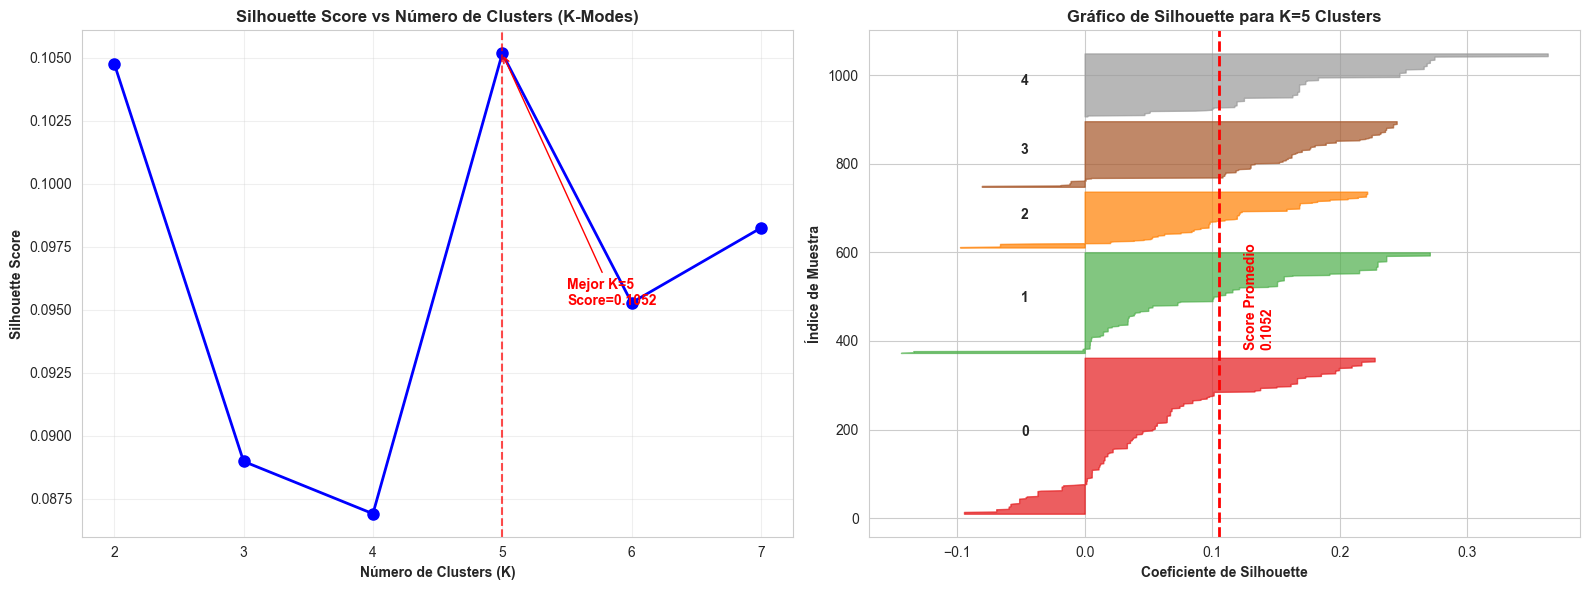


--- Análisis de Clusters (K=5) ---

Estadísticas por Cluster:
          Total                       Quantity Unit price
           mean  median     std count     mean       mean
Cluster                                                  
0        327.07  270.26  241.44   353     5.59      55.24
1        293.33  213.46  233.18   228     5.26      53.55
2        343.25  282.49  255.03   127     5.83      55.78
3        342.63  258.68  266.64   149     5.45      58.07
4        321.59  253.01  244.72   143     5.49      57.53

--- Composición Categórica por Cluster ---

Cluster 0 (n=353):
  Customer type: Normal (72.2%)
  Gender: Female (85.8%)
  Product line: Fashion (25.5%)
  Payment: Cash (47.0%)
  Rating_Category: Bueno (71.7%)

Cluster 1 (n=228):
  Customer type: Normal (67.1%)
  Gender: Male (89.5%)
  Product line: Home (34.6%)
  Payment: Ewallet (83.3%)
  Rating_Category: Bueno (62.7%)

Cluster 2 (n=127):
  Customer type: Normal (58.3%)
  Gender: Male (76.4%)
  Product line: Home (21

In [33]:
from sklearn.metrics import silhouette_score, silhouette_samples

# Análisis de Silhouette para diferentes números de clusters con K-Modes
import matplotlib.patches as mpatches

# Preparar datos categóricos para K-Modes
df_cat_encoded = df_eda[categorical_cols].apply(lambda x: pd.factorize(x)[0])

# Calcular Silhouette Score para diferentes valores de K
K_range = range(2, 8)
silhouette_scores = []

print("--- Análisis de Silhouette para K-Modes ---")
for k in K_range:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    cluster_labels = kmode.fit_predict(df_cat_encoded)
    
    # Convertir datos a formato numérico para silhouette_score
    # Usar One-Hot Encoding temporal para el cálculo de silhouette
    df_temp = pd.get_dummies(df_eda[categorical_cols])
    silhouette_avg = silhouette_score(df_temp, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"K={k}: Silhouette Score = {silhouette_avg:.4f}")

# Crear visualización de Silhouette Scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Silhouette Score vs Número de Clusters
ax1.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)', fontweight='bold')
ax1.set_ylabel('Silhouette Score', fontweight='bold')
ax1.set_title('Silhouette Score vs Número de Clusters (K-Modes)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Marcar el mejor K
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax1.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
ax1.annotate(f'Mejor K={best_k}\nScore={best_score:.4f}', 
             xy=(best_k, best_score), xytext=(best_k+0.5, best_score-0.01),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontweight='bold', color='red')

# Gráfico 2: Silhouette Plot detallado para el mejor K
kmode_best = KModes(n_clusters=best_k, init='Huang', n_init=5, verbose=0, random_state=42)
cluster_labels_best = kmode_best.fit_predict(df_cat_encoded)

# Calcular silhouette samples para el plot detallado
df_temp_best = pd.get_dummies(df_eda[categorical_cols])
sample_silhouette_values = silhouette_samples(df_temp_best, cluster_labels_best)

y_lower = 10
colors = plt.cm.Set1(np.linspace(0, 1, best_k))

for i in range(best_k):
    # Agregar silhouette scores para cluster i
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels_best == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # Etiquetar los clusters con su número en el centro
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')
    y_lower = y_upper + 10

ax2.set_xlabel('Coeficiente de Silhouette', fontweight='bold')
ax2.set_ylabel('Índice de Muestra', fontweight='bold')
ax2.set_title(f'Gráfico de Silhouette para K={best_k} Clusters', fontweight='bold')

# Línea vertical para el score promedio
ax2.axvline(x=best_score, color="red", linestyle="--", linewidth=2)
ax2.text(best_score+0.02, len(df_eda)/2, f'Score Promedio\n{best_score:.4f}', 
         rotation=90, verticalalignment='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Análisis de los clusters resultantes
print(f"\n--- Análisis de Clusters (K={best_k}) ---")
df_eda_clustered = df_eda.copy()
df_eda_clustered['Cluster'] = cluster_labels_best

# Estadísticas por cluster
cluster_stats = df_eda_clustered.groupby('Cluster').agg({
    'Total': ['mean', 'median', 'std', 'count'],
    'Quantity': 'mean',
    'Unit price': 'mean'
}).round(2)

print("\nEstadísticas por Cluster:")
print(cluster_stats)

# Composición categórica de cada cluster
print(f"\n--- Composición Categórica por Cluster ---")
for i in range(best_k):
    cluster_data = df_eda_clustered[df_eda_clustered['Cluster'] == i]
    print(f"\nCluster {i} (n={len(cluster_data)}):")
    
    for col in categorical_cols:
        mode_val = cluster_data[col].mode()[0]
        pct = (cluster_data[col] == mode_val).mean() * 100
        print(f"  {col}: {mode_val} ({pct:.1f}%)")

# 💡 Interpretación de Resultados
print(f"\n💡 INTERPRETACIÓN DEL ANÁLISIS DE SILHOUETTE:")
print(f"• Mejor número de clusters: {best_k}")
print(f"• Score de Silhouette: {best_score:.4f}")

if best_score > 0.5:
    print("• Calidad del clustering: EXCELENTE (>0.5)")
elif best_score > 0.3:
    print("• Calidad del clustering: BUENA (0.3-0.5)")
elif best_score > 0.1:
    print("• Calidad del clustering: MODERADA (0.1-0.3)")
else:
    print("• Calidad del clustering: POBRE (<0.1)")

print(f"• Los clusters muestran separación {'clara' if best_score > 0.3 else 'limitada'} entre grupos")
print(f"• Recomendación: {'Usar este clustering' if best_score > 0.2 else 'Considerar otras técnicas o variables'}")

In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from kneed import KneeLocator
import numpy as np
import pandas as pd
from kmodes.kmodes import KModes
import warnings
from collections import Counter

# Técnicas adicionales para determinar el número óptimo de clusters
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# --- 1. ÍNDICE DE CALINSKI-HARABASZ (Variance Ratio Criterion) ---
print("=== 1. ÍNDICE DE CALINSKI-HARABASZ ===")
print("Mide la relación entre dispersión entre clusters vs dentro de clusters")
print("Valor MÁS ALTO indica mejor clustering\n")

ch_scores = []
K_range = range(2, 10)

for k in K_range:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    cluster_labels = kmode.fit_predict(df_cat_encoded)
    
    # Usar OHE para calcular métricas
    df_temp = pd.get_dummies(df_eda[categorical_cols])
    ch_score = calinski_harabasz_score(df_temp, cluster_labels)
    ch_scores.append(ch_score)
    print(f"K={k}: Calinski-Harabasz = {ch_score:.2f}")

best_k_ch = K_range[np.argmax(ch_scores)]
print(f"\n🏆 Mejor K según Calinski-Harabasz: {best_k_ch}")

# --- 2. ÍNDICE DE DAVIES-BOULDIN ---
print("\n=== 2. ÍNDICE DE DAVIES-BOULDIN ===")
print("Mide la compacidad y separación de clusters")
print("Valor MÁS BAJO indica mejor clustering\n")

db_scores = []
for k in K_range:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    cluster_labels = kmode.fit_predict(df_cat_encoded)
    
    df_temp = pd.get_dummies(df_eda[categorical_cols])
    db_score = davies_bouldin_score(df_temp, cluster_labels)
    db_scores.append(db_score)
    print(f"K={k}: Davies-Bouldin = {db_score:.3f}")

best_k_db = K_range[np.argmin(db_scores)]
print(f"\n🏆 Mejor K según Davies-Bouldin: {best_k_db}")

# --- 3. MÉTODO DEL CODO MEJORADO CON KNEELOCATOR ---
print("\n=== 3. MÉTODO DEL CODO AUTOMATIZADO ===")
print("Detecta automáticamente el 'codo' en la curva de costos\n")

# Usar los costos ya calculados anteriormente
try:
    kl = KneeLocator(K, cost, curve="convex", direction="decreasing")
    knee_k = kl.knee
    print(f"🏆 K detectado automáticamente (Knee): {knee_k}")
except:
    print("❌ No se pudo detectar un codo claro automáticamente")

# --- 4. CLUSTERING JERÁRQUICO + DENDROGRAMA ---
print("\n=== 4. ANÁLISIS DE DENDROGRAMA (CLUSTERING JERÁRQUICO) ===")
print("Visualiza la estructura jerárquica de los datos para determinar cortes naturales\n")

# Usar una muestra para visualización (dendrograma completo es muy denso)
sample_size = 100
df_sample = df_temp.sample(n=min(sample_size, len(df_temp)), random_state=42)

# Clustering jerárquico
linkage_matrix = linkage(df_sample, method='ward')

# Crear dendrograma
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dendrograma completo
dendrogram(linkage_matrix, ax=ax1, truncate_mode='level', p=10)
ax1.set_title('Dendrograma (Muestra de datos)')
ax1.set_xlabel('Índice de Muestra')
ax1.set_ylabel('Distancia')

# Dendrograma truncado para mejor visualización
dendrogram(linkage_matrix, ax=ax2, truncate_mode='lastp', p=12, show_leaf_counts=True)
ax2.set_title('Dendrograma Truncado (Últimas 12 fusiones)')
ax2.set_xlabel('Tamaño de Cluster')
ax2.set_ylabel('Distancia')

plt.tight_layout()
plt.show()

# --- 5. COMPARACIÓN VISUAL DE TODAS LAS MÉTRICAS ---
print("\n=== 5. COMPARACIÓN VISUAL DE TODAS LAS MÉTRICAS ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Método del Codo
axes[0,0].plot(K, cost, 'bo-', linewidth=2, markersize=8)
axes[0,0].set_title('Método del Codo (K-Modes Cost)', fontweight='bold')
axes[0,0].set_xlabel('Número de Clusters (K)')
axes[0,0].set_ylabel('Costo')
axes[0,0].grid(True, alpha=0.3)

# Recalcular silhouette scores para el rango correcto
silhouette_scores_corrected = []
for k in K_range:
    kmode = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0, random_state=42)
    cluster_labels = kmode.fit_predict(df_cat_encoded)
    
    df_temp = pd.get_dummies(df_eda[categorical_cols])
    sil_score = silhouette_score(df_temp, cluster_labels)
    silhouette_scores_corrected.append(sil_score)

best_sil_k = K_range[np.argmax(silhouette_scores_corrected)]

# Gráfico 2: Silhouette Score
axes[0,1].plot(K_range, silhouette_scores_corrected, 'ro-', linewidth=2, markersize=8)
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('Número de Clusters (K)')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.7)

# Gráfico 3: Calinski-Harabasz
axes[1,0].plot(K_range, ch_scores, 'go-', linewidth=2, markersize=8)
axes[1,0].set_title('Calinski-Harabasz Score', fontweight='bold')
axes[1,0].set_xlabel('Número de Clusters (K)')
axes[1,0].set_ylabel('Calinski-Harabasz Score')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axvline(x=best_k_ch, color='green', linestyle='--', alpha=0.7)

# Gráfico 4: Davies-Bouldin
axes[1,1].plot(K_range, db_scores, 'mo-', linewidth=2, markersize=8)
axes[1,1].set_title('Davies-Bouldin Score', fontweight='bold')
axes[1,1].set_xlabel('Número de Clusters (K)')
axes[1,1].set_ylabel('Davies-Bouldin Score')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axvline(x=best_k_db, color='magenta', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 6. TABLA RESUMEN DE RECOMENDACIONES ---
print("\n" + "="*60)
print("📊 RESUMEN DE RECOMENDACIONES POR MÉTODO")
print("="*60)

methods_results = {
    'Método': ['Codo (Visual)', 'Codo (Automático)', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'],
    'K_Recomendado': [
        '3-4 (visual)', 
        str(knee_k) if 'knee_k' in locals() else 'No detectado',
        str(best_sil_k),
        str(best_k_ch),
        str(best_k_db)
    ],
    'Criterio': [
        'Inspección visual',
        'Detección automática', 
        'Máximo score',
        'Máximo score',
        'Mínimo score'
    ]
}

results_df = pd.DataFrame(methods_results)
print(results_df.to_string(index=False))

# Calcular consenso
all_ks = [best_sil_k, best_k_ch, best_k_db]
if 'knee_k' in locals() and knee_k is not None:
    all_ks.append(knee_k)

k_counts = Counter(all_ks)
consensus_k = k_counts.most_common(1)[0][0]

print(f"\n🎯 CONSENSO: K = {consensus_k} (recomendado por {k_counts[consensus_k]} métodos)")

# --- 7. TÉCNICAS ADICIONALES RECOMENDADAS ---
print(f"\n💡 OTRAS TÉCNICAS AVANZADAS DISPONIBLES:")
print(f"├── Gap Statistic: Compara clustering con datos aleatorios")
print(f"├── X-Means: Extensión automática de K-Means")
print(f"├── G-Means: Usa test de Gaussianidad")
print(f"├── Information Criterion (AIC/BIC): Para modelos probabilísticos")
print(f"├── Stability Analysis: Evalúa consistencia del clustering")
print(f"└── Domain Knowledge: Interpretación de negocio")

print(f"\n🔍 RECOMENDACIÓN FINAL:")
print(f"Para datos categóricos como los tuyos, el consenso entre múltiples")
print(f"métricas sugiere usar K={consensus_k} clusters. Sin embargo, siempre")
print(f"considera la interpretabilidad de negocio y valida los resultados.")

SyntaxError: invalid syntax (2910499882.py, line 162)